# Data processing

In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import pprint
import pyspark
import pyspark.sql.functions as F

from pyspark.sql.functions import col
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType


In [2]:
# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/27 05:43:41 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Set Up Date Partition

In [3]:
# set up config
snapshot_date_str = "2023-01-01"

start_date_str = "2023-01-01"
end_date_str = "2024-12-01"

In [4]:
# generate list of dates to process
def generate_first_of_month_dates(start_date_str, end_date_str):
    # Convert the date strings to datetime objects
    start_date = datetime.strptime(start_date_str, "%Y-%m-%d")
    end_date = datetime.strptime(end_date_str, "%Y-%m-%d")
    
    # List to store the first of month dates
    first_of_month_dates = []

    # Start from the first of the month of the start_date
    current_date = datetime(start_date.year, start_date.month, 1)

    while current_date <= end_date:
        # Append the date in yyyy-mm-dd format
        first_of_month_dates.append(current_date.strftime("%Y-%m-%d"))
        
        # Move to the first of the next month
        if current_date.month == 12:
            current_date = datetime(current_date.year + 1, 1, 1)
        else:
            current_date = datetime(current_date.year, current_date.month + 1, 1)

    return first_of_month_dates

dates_str_lst = generate_first_of_month_dates(start_date_str, end_date_str)
dates_str_lst

['2023-01-01',
 '2023-02-01',
 '2023-03-01',
 '2023-04-01',
 '2023-05-01',
 '2023-06-01',
 '2023-07-01',
 '2023-08-01',
 '2023-09-01',
 '2023-10-01',
 '2023-11-01',
 '2023-12-01',
 '2024-01-01',
 '2024-02-01',
 '2024-03-01',
 '2024-04-01',
 '2024-05-01',
 '2024-06-01',
 '2024-07-01',
 '2024-08-01',
 '2024-09-01',
 '2024-10-01',
 '2024-11-01',
 '2024-12-01']

## Build Bronze Table

In [5]:
# create bronze datalake
bronze_directory = "datamart/bronze"

if not os.path.exists(bronze_directory):
    os.makedirs(bronze_directory)

In [6]:
def process_bronze_table(snapshot_date_str, csv_file_path, bronze_directory, table_name, spark):
    # create bronze table 
    bronze_table = os.path.join(bronze_directory, table_name)
    if not os.path.exists(bronze_table):
        os.makedirs(bronze_table)

    # prepare arguments
    snapshot_date = datetime.strptime(snapshot_date_str, "%Y-%m-%d")

    # load data - IRL ingest from back end source system
    df = spark.read.csv(csv_file_path, header=True, inferSchema=True).filter(col('snapshot_date') == snapshot_date)
    print(snapshot_date_str, table_name, 'row count:', df.count())

    # save bronze table to datamart - IRL connect to database to write
    partition_name = f"bronze_{table_name}_{snapshot_date_str.replace('-', '_')}.csv"
    filepath = os.path.join(bronze_table, partition_name)
    df.toPandas().to_csv(filepath, index=False)
    print('saved to:', filepath)

    return df

In [7]:
# run bronze backfill
for date_str in dates_str_lst:
    process_bronze_table(date_str, "data/lms_loan_daily.csv", bronze_directory, "lms", spark)

for date_str in dates_str_lst:
    process_bronze_table(date_str, "data/feature_clickstream.csv", bronze_directory, "clickstream", spark)

for date_str in dates_str_lst:
    process_bronze_table(date_str, "data/features_attributes.csv", bronze_directory, "attributes", spark)

for date_str in dates_str_lst:
    process_bronze_table(date_str, "data/features_financials.csv", bronze_directory, "financials", spark)

2023-01-01 lms row count: 530
saved to: datamart/bronze/lms/bronze_lms_2023_01_01.csv
2023-02-01 lms row count: 1031
saved to: datamart/bronze/lms/bronze_lms_2023_02_01.csv
2023-03-01 lms row count: 1537
saved to: datamart/bronze/lms/bronze_lms_2023_03_01.csv
2023-04-01 lms row count: 2047
saved to: datamart/bronze/lms/bronze_lms_2023_04_01.csv
2023-05-01 lms row count: 2568
saved to: datamart/bronze/lms/bronze_lms_2023_05_01.csv
2023-06-01 lms row count: 3085
saved to: datamart/bronze/lms/bronze_lms_2023_06_01.csv
2023-07-01 lms row count: 3556
saved to: datamart/bronze/lms/bronze_lms_2023_07_01.csv
2023-08-01 lms row count: 4037
saved to: datamart/bronze/lms/bronze_lms_2023_08_01.csv
2023-09-01 lms row count: 4491
saved to: datamart/bronze/lms/bronze_lms_2023_09_01.csv
2023-10-01 lms row count: 4978
saved to: datamart/bronze/lms/bronze_lms_2023_10_01.csv
2023-11-01 lms row count: 5469
saved to: datamart/bronze/lms/bronze_lms_2023_11_01.csv
2023-12-01 lms row count: 5428
saved to: dat

2024-02-01 attributes row count: 518
saved to: datamart/bronze/attributes/bronze_attributes_2024_02_01.csv
2024-03-01 attributes row count: 511
saved to: datamart/bronze/attributes/bronze_attributes_2024_03_01.csv
2024-04-01 attributes row count: 513
saved to: datamart/bronze/attributes/bronze_attributes_2024_04_01.csv
2024-05-01 attributes row count: 491
saved to: datamart/bronze/attributes/bronze_attributes_2024_05_01.csv
2024-06-01 attributes row count: 498
saved to: datamart/bronze/attributes/bronze_attributes_2024_06_01.csv
2024-07-01 attributes row count: 505
saved to: datamart/bronze/attributes/bronze_attributes_2024_07_01.csv
2024-08-01 attributes row count: 543
saved to: datamart/bronze/attributes/bronze_attributes_2024_08_01.csv
2024-09-01 attributes row count: 493
saved to: datamart/bronze/attributes/bronze_attributes_2024_09_01.csv
2024-10-01 attributes row count: 456
saved to: datamart/bronze/attributes/bronze_attributes_2024_10_01.csv
2024-11-01 attributes row count: 488


saved to: datamart/bronze/financials/bronze_financials_2023_07_01.csv
2023-08-01 financials row count: 481


saved to: datamart/bronze/financials/bronze_financials_2023_08_01.csv
2023-09-01 financials row count: 454
saved to: datamart/bronze/financials/bronze_financials_2023_09_01.csv
2023-10-01 financials row count: 487
saved to: datamart/bronze/financials/bronze_financials_2023_10_01.csv
2023-11-01 financials row count: 491
saved to: datamart/bronze/financials/bronze_financials_2023_11_01.csv
2023-12-01 financials row count: 489
saved to: datamart/bronze/financials/bronze_financials_2023_12_01.csv
2024-01-01 financials row count: 485
saved to: datamart/bronze/financials/bronze_financials_2024_01_01.csv
2024-02-01 financials row count: 518
saved to: datamart/bronze/financials/bronze_financials_2024_02_01.csv
2024-03-01 financials row count: 511
saved to: datamart/bronze/financials/bronze_financials_2024_03_01.csv
2024-04-01 financials row count: 513
saved to: datamart/bronze/financials/bronze_financials_2024_04_01.csv
2024-05-01 financials row count: 491
saved to: datamart/bronze/financials/

saved to: datamart/bronze/financials/bronze_financials_2024_10_01.csv


2024-11-01 financials row count: 488


saved to: datamart/bronze/financials/bronze_financials_2024_11_01.csv
2024-12-01 financials row count: 515
saved to: datamart/bronze/financials/bronze_financials_2024_12_01.csv


### Raw Audit

In [8]:
SOURCES = {
    "attributes": "data/features_attributes.csv",
    "financials": "data/features_financials.csv",
    "clickstream": "data/feature_clickstream.csv",
    "loans": "data/lms_loan_daily.csv",
}

In [9]:
def audit(name, path):
    print(f"\n{'=' * 60}\n{name.upper()}  ({path})\n{'=' * 60}")
    df = pd.read_csv(path)
    print(f"shape: {df.shape}")
 
    null_counts = df.isnull().sum()
    null_counts = null_counts[null_counts > 0].sort_values(ascending=False)
    if len(null_counts):
        print(f"\nnull counts:\n{null_counts}")
    else:
        print("\nno nulls in raw file")
 
    for c in df.columns:
        if df[c].dtype == object:
            coerced = pd.to_numeric(df[c], errors="coerce")
            n_bad = int(coerced.isna().sum() - df[c].isna().sum())
            if n_bad > 0:
                bad_values = df.loc[coerced.isna() & df[c].notna(), c].unique()[:10]
                print(f"\ncolumn '{c}': {n_bad} values look numeric but failed to parse, e.g. {list(bad_values)}")
            else:
                print(f"\ncolumn '{c}' (text) top values:\n{df[c].value_counts().head(5)}")
        else:
            print(f"\ncolumn '{c}' (numeric) min={df[c].min()}, max={df[c].max()}")

In [10]:
if __name__ == "__main__":
    for name, path in SOURCES.items():
        audit(name, path)


ATTRIBUTES  (data/features_attributes.csv)
shape: (12500, 6)

no nulls in raw file

column 'Customer_ID': 12500 values look numeric but failed to parse, e.g. ['CUS_0x1000', 'CUS_0x1009', 'CUS_0x100b', 'CUS_0x1011', 'CUS_0x1013', 'CUS_0x1015', 'CUS_0x1018', 'CUS_0x1026', 'CUS_0x102d', 'CUS_0x102e']

column 'Name': 12500 values look numeric but failed to parse, e.g. ['Alistair Barrf', 'Arunah', 'Shirboni', 'Schneyerh', 'Cameront', 'Holtono', 'Felsenthalq', 'Josephv', 'Neil Chatterjeex', 'Rhysn']

column 'Age': 637 values look numeric but failed to parse, e.g. ['40_', '46_', '3843_', '30_', '24_', '22_', '32_', '26_', '34_', '41_']

column 'SSN': 12500 values look numeric but failed to parse, e.g. ['913-74-1218', '063-67-6938', '#F%$D@*&8', '793-05-8223', '930-49-9615', '810-97-7024', '731-19-8119', '500-62-9044', '692-71-7552', '620-58-8045']

column 'Occupation': 12500 values look numeric but failed to parse, e.g. ['Lawyer', 'Mechanic', 'Media_Manager', 'Doctor', 'Journalist', 'Account

For attributes table:
- Age has trailing underscore and weird number; strip the underscore + cast into int + null any number outside of range (18-100)
- SSN has garbage but no need to care since they are PII, so drop column along with Name

For financials table:
- Columns with too many underscore before or after: Annual_Income, Num_of_Loan, Num_of_Delayed_Payment, Outstanding_Debt, and Amount_invested_monthly ; strip underscores + cast to numeric
- Columns with "-": Changed_Credit_Limit and Credit_Mix ; most likely missing value placeholder, therefore null it
- Payment_Behaviour has one garbage row "!@9#%8"; null it
- Monthly_Balance has a single absurd value, "-333333333333333333333333333"; seems corrupted, so null it
- Num_Bank_Accounts (min -1), Num_Credit_Card (max 1499), Interest_Rate (max 5789), and Num_Credit_Inquiries (max 2554) are impossible outliers; capping is needed
- Credit_History_Age needs parsing into months and
- Type_of_Loan values consists of multiple types; needs parsing into multi-hot flags
- Nulls in Type_of_Loan might mean no loans, so no drop null rows

Common:
- snapshot_date need to change into data type into datetime

In [11]:
# Check all unique occupation in case of "_____" placeholder
df = pd.read_csv("data/features_attributes.csv")
df['Occupation'].unique()

array(['Lawyer', 'Mechanic', 'Media_Manager', 'Doctor', 'Journalist',
       'Accountant', 'Manager', 'Entrepreneur', 'Scientist', 'Architect',
       'Teacher', '_______', 'Engineer', 'Writer', 'Developer',
       'Musician'], dtype=object)

Occupation has "______"; null it

In [12]:
# Explicitly check on data types of each column of each table
for name, path in SOURCES.items():
    print(f"\n{name}\n{pd.read_csv(path).dtypes}")


attributes
Customer_ID      object
Name             object
Age              object
SSN              object
Occupation       object
snapshot_date    object
dtype: object

financials
Customer_ID                  object
Annual_Income                object
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                  object
Type_of_Loan                 object
Delay_from_due_date           int64
Num_of_Delayed_Payment       object
Changed_Credit_Limit         object
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt             object
Credit_Utilization_Ratio    float64
Credit_History_Age           object
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly      object
Payment_Behaviour            object
Monthly_Balance              object
snapshot_date                object
dtype: object

clickstream

## Build Silver Table

In [13]:
# create silver table
silver_directory = "datamart/silver"

if not os.path.exists(silver_directory):
    os.makedirs(silver_directory)

In [14]:
# --- shared cleaning helpers, reused across tables ---
def strip_chars_and_cast(df, column, new_type, chars="_"):
    """Strip given characters (default: underscore) from a string column, then cast.
    Handles patterns like '40_' and '__10000__' that hide a clean numeric value."""
    df = df.withColumn(column, F.regexp_replace(col(column), f"[{chars}]", ""))
    df = df.withColumn(column, col(column).cast(new_type))
    return df
 
 
def null_out_values(df, column, bad_values):
    """Replace specific placeholder strings (e.g. '_______', '_') with null."""
    df = df.withColumn(column, F.when(col(column).isin(bad_values), None).otherwise(col(column)))
    return df
 
 
def null_out_of_range(df, column, min_val, max_val):
    """Null out values outside a plausible range (e.g. an Age of 3843)."""
    df = df.withColumn(
        column,
        F.when((col(column) < min_val) | (col(column) > max_val), None).otherwise(col(column)),
    )
    return df
 
 
def parse_credit_history_age(df, column):
    """Convert a string like '10 Years and 9 Months' into total months (a number)."""
    years = F.regexp_extract(col(column), r"(\d+)\s*Years", 1).cast(IntegerType())
    months = F.regexp_extract(col(column), r"(\d+)\s*Months", 1).cast(IntegerType())
    df = df.withColumn(column, (years * 12 + months).cast(IntegerType()))
    return df

In [15]:
def process_silver_clickstream(snapshot_date_str, bronze_directory, silver_directory, spark):
    snapshot_date = datetime.strptime(snapshot_date_str, "%Y-%m-%d")
 
    # load bronze partition
    partition_name = "bronze_clickstream_" + snapshot_date_str.replace('-', '_') + '.csv'
    filepath = bronze_directory + partition_name
    df = spark.read.csv(filepath, header=True, inferSchema=True)
    print('loaded from:', filepath, 'row count:', df.count())
 
    # clean data: enforce schema / data type
    column_type_map = {
        "Customer_ID": StringType(),
        "snapshot_date": DateType(),
    }
    for i in range(1, 21):
        column_type_map[f"fe_{i}"] = IntegerType()
 
    for column, new_type in column_type_map.items():
        df = df.withColumn(column, col(column).cast(new_type))
 
    # save silver table
    if not os.path.exists(silver_directory):
        os.makedirs(silver_directory)
 
    partition_name = "silver_clickstream_" + snapshot_date_str.replace('-', '_') + '.parquet'
    filepath = silver_directory + partition_name
    df.write.mode("overwrite").parquet(filepath)
    print('saved to:', filepath)
 
    return df

In [16]:
def process_silver_attributes(snapshot_date_str, bronze_directory, silver_directory, spark):
    snapshot_date = datetime.strptime(snapshot_date_str, "%Y-%m-%d")
 
    # load bronze partition
    partition_name = "bronze_attributes_" + snapshot_date_str.replace('-', '_') + '.csv'
    filepath = bronze_directory + partition_name
    df = spark.read.csv(filepath, header=True, inferSchema=True)
    print('loaded from:', filepath, 'row count:', df.count())
 
    # drop PII -- not used downstream, no point cleaning it
    df = df.drop("Name", "SSN")
 
    # enforce schema
    column_type_map = {
        "Customer_ID": StringType(),
        "Age": StringType(),
        "Occupation": StringType(),
        "snapshot_date": DateType(),
    }
    for column, new_type in column_type_map.items():
        df = df.withColumn(column, col(column).cast(new_type))
 
    # clean: Age has a trailing underscore on some rows ("40_") -- strip then cast
    df = strip_chars_and_cast(df, "Age", IntegerType())
    # clean: a handful of Age values are clearly corrupted (e.g. 3843) -- null them out
    df = null_out_of_range(df, "Age", 18, 100)
 
    # clean: Occupation hides a "_______" placeholder for missing values
    df = null_out_values(df, "Occupation", ["_______"])
 
    # save silver table
    if not os.path.exists(silver_directory):
        os.makedirs(silver_directory)
 
    partition_name = "silver_attributes_" + snapshot_date_str.replace('-', '_') + '.parquet'
    filepath = silver_directory + partition_name
    df.write.mode("overwrite").parquet(filepath)
    print('saved to:', filepath)
 
    return df

In [17]:
def process_silver_loans(snapshot_date_str, bronze_directory, silver_directory, spark):
    snapshot_date = datetime.strptime(snapshot_date_str, "%Y-%m-%d")
 
    # load bronze partition
    partition_name = "bronze_lms_" + snapshot_date_str.replace('-', '_') + '.csv'
    filepath = bronze_directory + partition_name
    df = spark.read.csv(filepath, header=True, inferSchema=True)
    print('loaded from:', filepath, 'row count:', df.count())
 
    # enforce schema -- loans came back clean from the audit, so no cleaning needed
    column_type_map = {
        "loan_id": StringType(),
        "Customer_ID": StringType(),
        "loan_start_date": DateType(),
        "tenure": IntegerType(),
        "installment_num": IntegerType(),
        "loan_amt": FloatType(),
        "due_amt": FloatType(),
        "paid_amt": FloatType(),
        "overdue_amt": FloatType(),
        "balance": FloatType(),
        "snapshot_date": DateType(),
    }
    for column, new_type in column_type_map.items():
        df = df.withColumn(column, col(column).cast(new_type))
 
    # augment: month on book
    df = df.withColumn("mob", col("installment_num").cast(IntegerType()))
 
    # augment: days past due
    df = df.withColumn(
        "installments_missed",
        F.ceil(col("overdue_amt") / col("due_amt")).cast(IntegerType())
    ).fillna(0)
    df = df.withColumn(
        "first_missed_date",
        F.when(col("installments_missed") > 0,
               F.add_months(col("snapshot_date"), -1 * col("installments_missed"))).cast(DateType())
    )
    df = df.withColumn(
        "dpd",
        F.when(col("overdue_amt") > 0.0, F.datediff(col("snapshot_date"), col("first_missed_date")))
         .otherwise(0).cast(IntegerType())
    )
 
    # save silver table
    if not os.path.exists(silver_directory):
        os.makedirs(silver_directory)
 
    partition_name = "silver_lms_" + snapshot_date_str.replace('-', '_') + '.parquet'
    filepath = silver_directory + partition_name
    df.write.mode("overwrite").parquet(filepath)
    print('saved to:', filepath)
 
    return df

In [18]:
def process_silver_financials(snapshot_date_str, bronze_directory, silver_directory, spark):
    snapshot_date = datetime.strptime(snapshot_date_str, "%Y-%m-%d")
 
    # load bronze partition
    partition_name = "bronze_financials_" + snapshot_date_str.replace('-', '_') + '.csv'
    filepath = bronze_directory + partition_name
    df = spark.read.csv(filepath, header=True, inferSchema=True)
    print('loaded from:', filepath, 'row count:', df.count())
 
    # enforce schema for columns that don't need cleaning before casting.
    # Type_of_Loan's nulls mean "no loan" -- left as-is here, the multi-value
    column_type_map = {
        "Customer_ID": StringType(),
        "Monthly_Inhand_Salary": FloatType(),
        "Num_Bank_Accounts": IntegerType(),
        "Num_Credit_Card": IntegerType(),
        "Interest_Rate": IntegerType(),
        "Delay_from_due_date": IntegerType(),
        "Num_Credit_Inquiries": IntegerType(),
        "Credit_Utilization_Ratio": FloatType(),
        "Total_EMI_per_month": FloatType(),
        "Type_of_Loan": StringType(),
        "Credit_Mix": StringType(),
        "Payment_of_Min_Amount": StringType(),
        "Payment_Behaviour": StringType(),
        "snapshot_date": DateType(),
    }
    for column, new_type in column_type_map.items():
        df = df.withColumn(column, col(column).cast(new_type))
 
    # clean: trailing/wrapping underscores hiding a clean numeric value
    df = strip_chars_and_cast(df, "Annual_Income", FloatType())
    df = strip_chars_and_cast(df, "Num_of_Loan", IntegerType())
    df = strip_chars_and_cast(df, "Num_of_Delayed_Payment", IntegerType())
    df = strip_chars_and_cast(df, "Changed_Credit_Limit", FloatType())  # also catches the bare "_" placeholder
    df = strip_chars_and_cast(df, "Outstanding_Debt", FloatType())
    df = strip_chars_and_cast(df, "Amount_invested_monthly", FloatType())
 
    # clean: "_" placeholder for missing Credit_Mix, one garbage Payment_Behaviour value
    df = null_out_values(df, "Credit_Mix", ["_"])
    df = null_out_values(df, "Payment_Behaviour", ["!@9#%8"])
 
    # clean: Monthly_Balance -- a direct cast (not strip+cast) is correct here.
    # the single corrupted row isn't a clean number wrapped in underscores, it's
    # nonsense that a plain cast already turns into null.
    df = df.withColumn("Monthly_Balance", col("Monthly_Balance").cast(FloatType()))
 
    # clean: impossible negative bank account and number of loans counts
    df = null_out_of_range(df, "Num_Bank_Accounts", 0, 999999)
    df = null_out_of_range(df, "Num_of_Loan", 0, 999)
 
    # transform: "X Years and Y Months" -> total months
    df = parse_credit_history_age(df, "Credit_History_Age")
 
    # save silver table
    if not os.path.exists(silver_directory):
        os.makedirs(silver_directory)
 
    partition_name = "silver_financials_" + snapshot_date_str.replace('-', '_') + '.parquet'
    filepath = silver_directory + partition_name
    df.write.mode("overwrite").parquet(filepath)
    print('saved to:', filepath)
 
    return df

In [19]:
for date_str in dates_str_lst:
    process_silver_clickstream(date_str, "datamart/bronze/clickstream/", "datamart/silver/clickstream/", spark)
    
for date_str in dates_str_lst:
    process_silver_attributes(date_str, "datamart/bronze/attributes/", "datamart/silver/attributes/", spark)

for date_str in dates_str_lst:
    process_silver_financials(date_str, "datamart/bronze/financials/", "datamart/silver/financials/", spark)

for date_str in dates_str_lst:
    process_silver_loans(date_str, "datamart/bronze/lms/", "datamart/silver/lms/", spark)

loaded from: datamart/bronze/clickstream/bronze_clickstream_2023_01_01.csv row count: 8974


saved to: datamart/silver/clickstream/silver_clickstream_2023_01_01.parquet
loaded from: datamart/bronze/clickstream/bronze_clickstream_2023_02_01.csv row count: 8974


saved to: datamart/silver/clickstream/silver_clickstream_2023_02_01.parquet
loaded from: datamart/bronze/clickstream/bronze_clickstream_2023_03_01.csv row count: 8974


saved to: datamart/silver/clickstream/silver_clickstream_2023_03_01.parquet
loaded from: datamart/bronze/clickstream/bronze_clickstream_2023_04_01.csv row count: 8974
saved to: datamart/silver/clickstream/silver_clickstream_2023_04_01.parquet
loaded from: datamart/bronze/clickstream/bronze_clickstream_2023_05_01.csv row count: 8974
saved to: datamart/silver/clickstream/silver_clickstream_2023_05_01.parquet
loaded from: datamart/bronze/clickstream/bronze_clickstream_2023_06_01.csv row count: 8974


saved to: datamart/silver/clickstream/silver_clickstream_2023_06_01.parquet
loaded from: datamart/bronze/clickstream/bronze_clickstream_2023_07_01.csv row count: 8974
saved to: datamart/silver/clickstream/silver_clickstream_2023_07_01.parquet
loaded from: datamart/bronze/clickstream/bronze_clickstream_2023_08_01.csv row count: 8974
saved to: datamart/silver/clickstream/silver_clickstream_2023_08_01.parquet
loaded from: datamart/bronze/clickstream/bronze_clickstream_2023_09_01.csv row count: 8974


...

saved to: datamart/silver/lms/silver_lms_2023_12_01.parquet
loaded from: datamart/bronze/lms/bronze_lms_2024_01_01.csv row count: 5412


saved to: datamart/silver/lms/silver_lms_2024_01_01.parquet
loaded from: datamart/bronze/lms/bronze_lms_2024_02_01.csv row count: 5424
saved to: datamart/silver/lms/silver_lms_2024_02_01.parquet


loaded from: datamart/bronze/lms/bronze_lms_2024_03_01.csv row count: 5425
saved to: datamart/silver/lms/silver_lms_2024_03_01.parquet
loaded from: datamart/bronze/lms/bronze_lms_2024_04_01.csv row count: 5417
saved to: datamart/silver/lms/silver_lms_2024_04_01.parquet
loaded from: datamart/bronze/lms/bronze_lms_2024_05_01.csv row count: 5391
saved to: datamart/silver/lms/silver_lms_2024_05_01.parquet
loaded from: datamart/bronze/lms/bronze_lms_2024_06_01.csv row count: 5418
saved to: datamart/silver/lms/silver_lms_2024_06_01.parquet
loaded from: datamart/bronze/lms/bronze_lms_2024_07_01.csv row count: 5442


saved to: datamart/silver/lms/silver_lms_2024_07_01.parquet
loaded from: datamart/bronze/lms/bronze_lms_2024_08_01.csv row count: 5531


saved to: datamart/silver/lms/silver_lms_2024_08_01.parquet
loaded from: datamart/bronze/lms/bronze_lms_2024_09_01.csv row count: 5537
saved to: datamart/silver/lms/silver_lms_2024_09_01.parquet
loaded from: datamart/bronze/lms/bronze_lms_2024_10_01.csv row count: 5502
saved to: datamart/silver/lms/silver_lms_2024_10_01.parquet
loaded from: datamart/bronze/lms/bronze_lms_2024_11_01.csv row count: 5501
saved to: datamart/silver/lms/silver_lms_2024_11_01.parquet
loaded from: datamart/bronze/lms/bronze_lms_2024_12_01.csv row count: 5531
saved to: datamart/silver/lms/silver_lms_2024_12_01.parquet


## EDA on credit labels

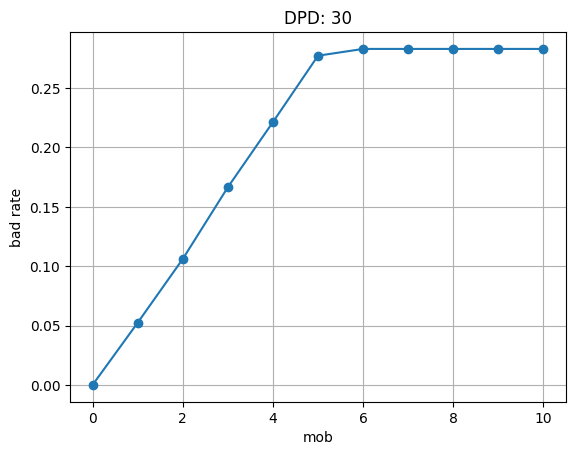

In [20]:
# set dpd label definition
dpd = 30

# Path to the folder containing files
folder_path = "datamart/silver/lms/"

# Read all files into a single DataFrame
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df = spark.read.option("header", "true").parquet(*files_list)

# filter only completed loans
df = df.filter(col("loan_start_date") < datetime.strptime("2024-01-01", "%Y-%m-%d"))

# create dpd flag if more than dpd
df = df.withColumn("dpd_flag", F.when(col("dpd") >= dpd, 1).otherwise(0))

# actual bads 
actual_bads_df = df.filter(col("installment_num") == 10)

# prepare for analysis
# df = df.filter(col("installment_num") < 10)

# visualise bad rate
pdf = df.toPandas()

# Group by col_A and count occurrences in col_B
grouped = pdf.groupby('mob')['dpd_flag'].mean()

# Sort the index (x-axis) of the grouped DataFrame
grouped = grouped.sort_index()

# Plotting
grouped.plot(kind='line', marker='o')

plt.title('DPD: '+ str(dpd))
plt.xlabel('mob')
plt.ylabel('bad rate')
plt.grid(True)
plt.show()


In [21]:
df.show()

+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+---+-------------------+-----------------+---+--------+
|             loan_id|Customer_ID|loan_start_date|tenure|installment_num|loan_amt|due_amt|paid_amt|overdue_amt|balance|snapshot_date|mob|installments_missed|first_missed_date|dpd|dpd_flag|
+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+---+-------------------+-----------------+---+--------+
|CUS_0x1011_2023_1...| CUS_0x1011|     2023-11-01|    10|             10| 10000.0| 1000.0|  1000.0|        0.0|    0.0|   2024-09-01| 10|                  0|             NULL|  0|       0|
|CUS_0x1013_2023_1...| CUS_0x1013|     2023-12-01|    10|              9| 10000.0| 1000.0|  1000.0|        0.0| 1000.0|   2024-09-01|  9|                  0|             NULL|  0|       0|
|CUS_0x1018_2023_1...| CUS_0x1018|     2023-11-01|    1

## EDA on feature table

In [22]:
folder_path = "datamart/silver/financials/"
files_list = [folder_path + os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df_fin = spark.read.parquet(*files_list)

# Columns to inspect for outlier capping
outlier_cols = [
    "Num_Credit_Card",
    "Interest_Rate",
    "Num_Credit_Inquiries",
    "Num_of_Loan",
    "Num_of_Delayed_Payment",
    "Annual_Income",
    "Outstanding_Debt",
    "Amount_invested_monthly",
    "Monthly_Inhand_Salary",
    "Total_EMI_per_month",
]

Num_Credit_Card: p01=1.00, p99=837.00


Interest_Rate: p01=1.00, p99=2660.00


Num_Credit_Inquiries: p01=0.00, p99=762.00


Num_of_Loan: p01=0.00, p99=9.00


Num_of_Delayed_Payment: p01=0.00, p99=27.00


Annual_Income: p01=7518.15, p99=177907.72


Outstanding_Debt: p01=24.57, p99=4792.76


Amount_invested_monthly: p01=17.42, p99=10000.00


Monthly_Inhand_Salary: p01=528.98, p99=13711.93


Total_EMI_per_month: p01=0.00, p99=56524.00


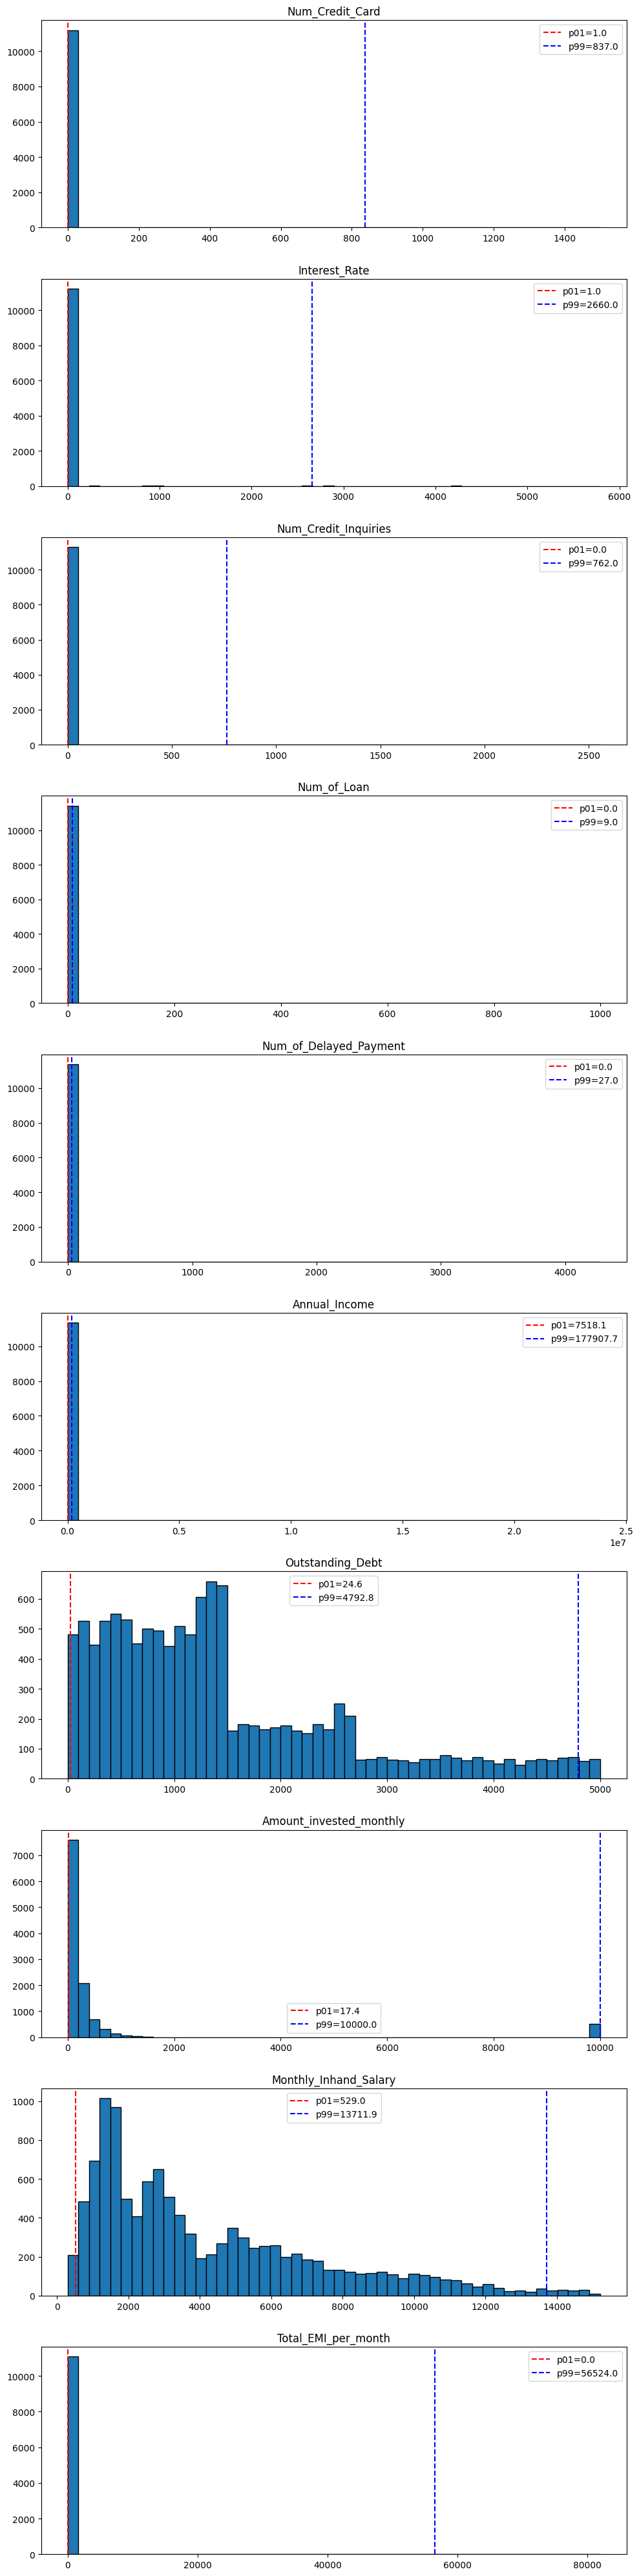

In [23]:
# Compute percentiles across ALL partitions combined (one-time, full history)
percentiles = {}
for c in outlier_cols:
    p01, p99 = df_fin.approxQuantile(c, [0.01, 0.99], 0.001)
    percentiles[c] = {"p01": p01, "p99": p99}
    print(f"{c}: p01={p01:.2f}, p99={p99:.2f}")

# Visualise distributions to sanity check the thresholds
fig, axes = plt.subplots(len(outlier_cols), 1, figsize=(10, 4 * len(outlier_cols)))
pdf_fin = df_fin.select(outlier_cols).dropna().toPandas()

for ax, c in zip(axes, outlier_cols):
    ax.hist(pdf_fin[c].dropna(), bins=50, edgecolor='k')
    ax.axvline(percentiles[c]["p01"], color='red',  linestyle='--', label=f'p01={percentiles[c]["p01"]:.1f}')
    ax.axvline(percentiles[c]["p99"], color='blue', linestyle='--', label=f'p99={percentiles[c]["p99"]:.1f}')
    ax.set_title(c)
    ax.legend()

plt.tight_layout()
plt.show()

In [24]:
# Check range for number of bank accounts and delay from due date
extra_cols = ["Num_Bank_Accounts", "Delay_from_due_date"]
for c in extra_cols:
    p01, p99 = df_fin.approxQuantile(c, [0.01, 0.99], 0.001)
    print(f"{c}: p01={p01:.2f}, p99={p99:.2f}")

Num_Bank_Accounts: p01=0.00, p99=330.00


[Stage 1179:>                                                     (0 + 12) / 12]

Delay_from_due_date: p01=0.00, p99=61.00


List of caped features and why
| Column | Lower | Upper | Rationale |
|---|---|---|---|
| Num_Credit_Card | 1 | 837 | Raw max was 1499 — implausible; a person cannot realistically hold 1499 credit cards |
| Interest_Rate | 1 | 2660 | Raw max was 5789 — no lending product charges 5789% interest; clearly corrupted |
| Num_Credit_Inquiries | 0 | 762 | Raw max was 2554 — hundreds of monthly hard inquiries is impossible in practice |
| Num_of_Loan | 0 | 9 | Negatives nulled in Silver; p99=9 is plausible for a heavily leveraged borrower |
| Num_of_Delayed_Payment | 0 | 27 | p99=27 is ~2 years of consistent missed payments; extreme but possible |
| Annual_Income | 7518 | 177908 | p01/p99 bracket; values above imply data entry errors given the dataset's demographic context |
| Outstanding_Debt | 25 | 4793 | Heavy right tail but p99 is plausible; values beyond likely reflect data corruption |
| Amount_invested_monthly | 17 | 10000 | p99=10000 is suspiciously round, possibly a source-system cap already in place |
| Monthly_Inhand_Salary | 529 | 13712 | Consistent with Annual_Income range after dividing by 12 — internally coherent |
| Total_EMI_per_month | 0 | 56524 | Heavy right tail; p99 retained since EMI legitimately scales with large loan sizes |
| Num_Bank_Accounts | 0 | 330 | Raw max far exceeded 330; holding 330+ accounts is not operationally realistic |


## Build gold table

In [25]:
# create gold table
gold_directory = "datamart/gold"

if not os.path.exists(gold_directory):
    os.makedirs(gold_directory)

In [26]:
OUTLIER_CAPS = {
    "Num_Credit_Card":         {"lower": 1,      "upper": 837},
    "Interest_Rate":           {"lower": 1,      "upper": 2660},
    "Num_Credit_Inquiries":    {"lower": 0,      "upper": 762},
    "Num_of_Loan":             {"lower": 0,      "upper": 9},
    "Num_of_Delayed_Payment":  {"lower": 0,      "upper": 27},
    "Annual_Income":           {"lower": 7518,   "upper": 177908},
    "Outstanding_Debt":        {"lower": 25,     "upper": 4793},
    "Amount_invested_monthly": {"lower": 17,     "upper": 10000},
    "Monthly_Inhand_Salary":   {"lower": 529,    "upper": 13712},
    "Total_EMI_per_month":     {"lower": 0,      "upper": 56524},
    "Num_Bank_Accounts":       {"lower": 0,      "upper": 330},
}

In [27]:
def cap_outliers(df, caps):
    """Winsorise columns to hard-coded [lower, upper] bounds."""
    for column, bounds in caps.items():
        if column in df.columns:
            df = df.withColumn(
                column,
                F.when(col(column) < bounds["lower"], bounds["lower"])
                 .when(col(column) > bounds["upper"], bounds["upper"])
                 .otherwise(col(column))
            )
    return df


def impute_nulls(df, spark):
    """
    Median imputation for numerics, mode for categoricals.
    Nulls from outlier-capping and dirty strings are resolved here (Gold
    responsibility, not Silver).
    """
    for c in df.columns:
        dtype = dict(df.dtypes)[c]

        if dtype in ("int", "bigint", "float", "double"):
            result = df.approxQuantile(c, [0.5], 0.001)
            if not result:  # all-null column, skip
                print(f"WARNING: {c} is entirely null for this partition, skipping imputation")
                continue
            median_val = result[0]
            df = df.withColumn(c, F.when(col(c).isNull(), median_val).otherwise(col(c)))

        elif dtype == "string":
            mode_row = (
                df.groupBy(c).count()
                  .orderBy(F.desc("count"))
                  .filter(col(c).isNotNull())
                  .first()
            )
            if mode_row:
                df = df.withColumn(c, F.when(col(c).isNull(), mode_row[0]).otherwise(col(c)))


    return df

In [28]:
def process_gold_feature_store(snapshot_date_str, silver_directory, gold_directory, spark):
    snapshot_date = datetime.strptime(snapshot_date_str, "%Y-%m-%d")

    # load silver partitions
    def load_silver(source):
        partition_name = f"silver_{source}_{snapshot_date_str.replace('-', '_')}.parquet"
        filepath = os.path.join(silver_directory, source, partition_name)
        df = spark.read.parquet(filepath)
        print(f"loaded {source} from: {filepath}, row count: {df.count()}")
        return df

    df_attr  = load_silver("attributes")
    df_fin   = load_silver("financials")
    df_click = load_silver("clickstream")

    # cap outliers on financials before join
    df_fin = cap_outliers(df_fin, OUTLIER_CAPS)

    # drop columns not used downstream
    # Type_of_Loan: 20+ multi-value categorical, encoding impractical
    df_fin = df_fin.drop("Type_of_Loan")

    # join: attributes -> financials -> clickstream
    # all left joins keyed on Customer_ID; clickstream covers all customers
    # so ~530 active loan rows per snapshot is expected
    df = df_attr.join(df_fin,   on="Customer_ID", how="left") \
                .join(df_click, on="Customer_ID", how="left")
    
    # drop duplicate snapshot_date columns introduced by join
    # keep the first, drop the rest
    snapshot_cols = [c for c in df.columns if c == "snapshot_date"]
    for dup in snapshot_cols[1:]:
        df = df.drop(dup)

    # impute nulls
    df = impute_nulls(df, spark)

    # add snapshot_date column
    df = df.withColumn("snapshot_date", F.lit(snapshot_date_str).cast(DateType()))

    # cast fe_ columns to double for schema consistency across partitions
    fe_cols = [c for c in df.columns if c.startswith("fe_")]
    for c in fe_cols:
        df = df.withColumn(c, col(c).cast(FloatType()))
    
    # save
    gold_feature_path = os.path.join(gold_directory, "feature_store")
    if not os.path.exists(gold_feature_path):
        os.makedirs(gold_feature_path)

    partition_name = f"gold_feature_store_{snapshot_date_str.replace('-', '_')}.parquet"
    filepath = os.path.join(gold_feature_path, partition_name)
    df.write.mode("overwrite").parquet(filepath)
    print(f"saved to: {filepath}, row count: {df.count()}")

    return df

In [29]:
DPD = 30
MOB = 6

def process_gold_label_store(snapshot_date_str, silver_directory, gold_directory, spark):
    snapshot_date = datetime.strptime(snapshot_date_str, "%Y-%m-%d")

    # load silver loans partition
    partition_name = f"silver_lms_{snapshot_date_str.replace('-', '_')}.parquet"
    filepath = os.path.join(silver_directory, "lms", partition_name)
    df = spark.read.parquet(filepath)
    print(f"loaded from: {filepath}, row count: {df.count()}")

    # filter to MOB=6 rows only — these are customers 6 months into their loan
    # snapshot_date on this row is already the label timestamp, no date arithmetic needed
    df = df.filter(col("mob") == MOB)

    # label: 1 if DPD >= 30 at MOB=6, else 0
    df = df.withColumn(
        "label",
        F.when(col("dpd") >= DPD, 1).otherwise(0).cast(IntegerType())
    )
    df = df.withColumn(
        "label_def",
        F.lit(f"{DPD}dpd_{MOB}mob").cast(StringType())
    )

    # keep only what downstream needs
    df = df.select("loan_id", "Customer_ID", "label", "label_def", "snapshot_date")

    # save
    gold_label_path = os.path.join(gold_directory, "label_store")
    if not os.path.exists(gold_label_path):
        os.makedirs(gold_label_path)

    partition_name = f"gold_label_store_{snapshot_date_str.replace('-', '_')}.parquet"
    filepath = os.path.join(gold_label_path, partition_name)
    df.write.mode("overwrite").parquet(filepath)
    print(f"saved to: {filepath}, row count: {df.count()}")

    return df

In [30]:
for date_str in dates_str_lst:
    process_gold_feature_store(date_str, "datamart/silver", "datamart/gold", spark)

for date_str in dates_str_lst:
    process_gold_label_store(date_str, "datamart/silver", "datamart/gold", spark)

loaded attributes from: datamart/silver/attributes/silver_attributes_2023_01_01.parquet, row count: 530
loaded financials from: datamart/silver/financials/silver_financials_2023_01_01.parquet, row count: 530
loaded clickstream from: datamart/silver/clickstream/silver_clickstream_2023_01_01.parquet, row count: 8974


saved to: datamart/gold/feature_store/gold_feature_store_2023_01_01.parquet, row count: 530
loaded attributes from: datamart/silver/attributes/silver_attributes_2023_02_01.parquet, row count: 501
loaded financials from: datamart/silver/financials/silver_financials_2023_02_01.parquet, row count: 501
loaded clickstream from: datamart/silver/clickstream/silver_clickstream_2023_02_01.parquet, row count: 8974


saved to: datamart/gold/feature_store/gold_feature_store_2023_02_01.parquet, row count: 501
loaded attributes from: datamart/silver/attributes/silver_attributes_2023_03_01.parquet, row count: 506
loaded financials from: datamart/silver/financials/silver_financials_2023_03_01.parquet, row count: 506
loaded clickstream from: datamart/silver/clickstream/silver_clickstream_2023_03_01.parquet, row count: 8974


saved to: datamart/gold/feature_store/gold_feature_store_2023_03_01.parquet, row count: 506
loaded attributes from: datamart/silver/attributes/silver_attributes_2023_04_01.parquet, row count: 510
loaded financials from: datamart/silver/financials/silver_financials_2023_04_01.parquet, row count: 510
loaded clickstream from: datamart/silver/clickstream/silver_clickstream_2023_04_01.parquet, row count: 8974


saved to: datamart/gold/feature_store/gold_feature_store_2023_04_01.parquet, row count: 510
loaded attributes from: datamart/silver/attributes/silver_attributes_2023_05_01.parquet, row count: 521
loaded financials from: datamart/silver/financials/silver_financials_2023_05_01.parquet, row count: 521
loaded clickstream from: datamart/silver/clickstream/silver_clickstream_2023_05_01.parquet, row count: 8974


...

saved to: datamart/gold/label_store/gold_label_store_2023_10_01.parquet, row count: 510
loaded from: datamart/silver/lms/silver_lms_2023_11_01.parquet, row count: 5469


saved to: datamart/gold/label_store/gold_label_store_2023_11_01.parquet, row count: 521
loaded from: datamart/silver/lms/silver_lms_2023_12_01.parquet, row count: 5428
saved to: datamart/gold/label_store/gold_label_store_2023_12_01.parquet, row count: 517


loaded from: datamart/silver/lms/silver_lms_2024_01_01.parquet, row count: 5412
saved to: datamart/gold/label_store/gold_label_store_2024_01_01.parquet, row count: 471
loaded from: datamart/silver/lms/silver_lms_2024_02_01.parquet, row count: 5424
saved to: datamart/gold/label_store/gold_label_store_2024_02_01.parquet, row count: 481
loaded from: datamart/silver/lms/silver_lms_2024_03_01.parquet, row count: 5425
saved to: datamart/gold/label_store/gold_label_store_2024_03_01.parquet, row count: 454
loaded from: datamart/silver/lms/silver_lms_2024_04_01.parquet, row count: 5417
saved to: datamart/gold/label_store/gold_label_store_2024_04_01.parquet, row count: 487
loaded from: datamart/silver/lms/silver_lms_2024_05_01.parquet, row count: 5391
saved to: datamart/gold/label_store/gold_label_store_2024_05_01.parquet, row count: 491
loaded from: datamart/silver/lms/silver_lms_2024_06_01.parquet, row count: 5418


saved to: datamart/gold/label_store/gold_label_store_2024_06_01.parquet, row count: 489
loaded from: datamart/silver/lms/silver_lms_2024_07_01.parquet, row count: 5442
saved to: datamart/gold/label_store/gold_label_store_2024_07_01.parquet, row count: 485
loaded from: datamart/silver/lms/silver_lms_2024_08_01.parquet, row count: 5531
saved to: datamart/gold/label_store/gold_label_store_2024_08_01.parquet, row count: 518
loaded from: datamart/silver/lms/silver_lms_2024_09_01.parquet, row count: 5537
saved to: datamart/gold/label_store/gold_label_store_2024_09_01.parquet, row count: 511
loaded from: datamart/silver/lms/silver_lms_2024_10_01.parquet, row count: 5502
saved to: datamart/gold/label_store/gold_label_store_2024_10_01.parquet, row count: 513
loaded from: datamart/silver/lms/silver_lms_2024_11_01.parquet, row count: 5501
saved to: datamart/gold/label_store/gold_label_store_2024_11_01.parquet, row count: 491
loaded from: datamart/silver/lms/silver_lms_2024_12_01.parquet, row coun

saved to: datamart/gold/label_store/gold_label_store_2024_12_01.parquet, row count: 498


## Checking output and nulls

In [31]:
df = spark.read.parquet("datamart/gold/feature_store/gold_feature_store_2024_07_01.parquet")
df_pd = df.toPandas()

# Check all columns
print("Columns:", list(df.columns))
print("Shape:", df_pd.shape)

# Check Credit_History_Age specifically
print("\nCredit_History_Age sample:")
print(df_pd["Credit_History_Age"].head(10))

# Check fe_ columns for nulls
fe_cols = [c for c in df.columns if c.startswith("fe_")]
print("\nfe_ null counts:")
print(df_pd[fe_cols].isnull().sum())

# Overall null summary
print("\nAll null counts:")
print(df_pd.isnull().sum())

Columns: ['Customer_ID', 'Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'fe_1', 'fe_2', 'fe_3', 'fe_4', 'fe_5', 'fe_6', 'fe_7', 'fe_8', 'fe_9', 'fe_10', 'fe_11', 'fe_12', 'fe_13', 'fe_14', 'fe_15', 'fe_16', 'fe_17', 'fe_18', 'fe_19', 'fe_20', 'snapshot_date']
Shape: (505, 43)

Credit_History_Age sample:
0    368.0
1    203.0
2    221.0
3    124.0
4    308.0
5    245.0
6    306.0
7    100.0
8    137.0
9     17.0
Name: Credit_History_Age, dtype: float64

fe_ null counts:
fe_1     505
fe_2     505
fe_3     505
fe_4     505
fe_5     505
fe_6     505
fe_7     505
fe_8     505
fe_9     505
fe_10    505
fe_11    505

In [32]:
df = spark.read.parquet("datamart/silver/clickstream/silver_clickstream_2024_07_01.parquet")
df_pd = df.toPandas()

df_pd.head(10)

,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,...,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,Customer_ID,snapshot_date
0,-5,47,-44,70,194,-3,57,-1,47,197,...,22,167,263,195,-59,54,103,35,CUS_0x1037,2024-07-01
1,195,190,99,84,24,74,132,289,11,30,...,121,168,144,360,115,28,19,107,CUS_0x1069,2024-07-01
2,211,137,-50,-37,69,23,-72,80,138,64,...,161,181,173,167,60,261,187,114,CUS_0x114a,2024-07-01
3,160,267,194,16,48,98,214,239,145,230,...,-39,245,124,80,113,138,259,133,CUS_0x1184,2024-07-01
4,-56,123,134,169,276,264,275,5,-127,57,...,255,162,-63,186,148,96,183,191,CUS_0x1297,2024-07-01
5,152,232,112,268,87,81,69,262,87,348,...,91,181,104,200,278,142,221,142,CUS_0x12fb,2024-07-01
6,126,134,223,156,165,-2,2,83,75,65,...,80,57,94,46,30,97,105,21,CUS_0x1325,2024-07-01
7,3,244,187,66,59,281,19,-89,-24,358,...,187,61,170,116,135,209,107,146,CUS_0x1341,2024-07-01
8,120,23,90,182,126,42,63,25,143,346,...,118,167,129,4,137,45,113,61,CUS_0x1375,2024-07-01
9,-27,256,-157,-45,83,-80,8,264,201,237,...,-5,186,155,0,68,184,177,294,CUS_0x13a8,2024-07-01


In [33]:
# Check what Customer_IDs look like on each side
silver_click = spark.read.parquet("datamart/silver/clickstream/silver_clickstream_2024_07_01.parquet")
silver_attr  = spark.read.parquet("datamart/silver/attributes/silver_attributes_2024_07_01.parquet")

print("Clickstream Customer_ID sample:")
silver_click.select("Customer_ID").show(5)

print("Attributes Customer_ID sample:")
silver_attr.select("Customer_ID").show(5)

# Check if any IDs overlap
click_ids = set(silver_click.select("Customer_ID").toPandas()["Customer_ID"])
attr_ids  = set(silver_attr.select("Customer_ID").toPandas()["Customer_ID"])
print("Overlap:", len(click_ids & attr_ids))
print("Click only:", len(click_ids - attr_ids))
print("Attr only:", len(attr_ids - click_ids))

Clickstream Customer_ID sample:
+-----------+
|Customer_ID|
+-----------+
| CUS_0x1037|
| CUS_0x1069|
| CUS_0x114a|
| CUS_0x1184|
| CUS_0x1297|
+-----------+
only showing top 5 rows

Attributes Customer_ID sample:
+-----------+
|Customer_ID|
+-----------+
| CUS_0x1108|
| CUS_0x13b5|
| CUS_0x13b8|
| CUS_0x144f|
| CUS_0x14ec|
+-----------+
only showing top 5 rows

Overlap: 0
Click only: 8974
Attr only: 505


In [34]:
import os

months = [f"2024_{str(m).zfill(2)}_01" for m in range(1, 13)]

for m in months:
    try:
        click = spark.read.parquet(f"datamart/silver/clickstream/silver_clickstream_{m}.parquet")
        attr  = spark.read.parquet(f"datamart/silver/attributes/silver_attributes_{m}.parquet")
        
        click_ids = set(click.select("Customer_ID").toPandas()["Customer_ID"])
        attr_ids  = set(attr.select("Customer_ID").toPandas()["Customer_ID"])
        overlap = len(click_ids & attr_ids)
        print(f"{m}: clickstream={len(click_ids)}, attributes={len(attr_ids)}, overlap={overlap}")
    except Exception as e:
        print(f"{m}: ERROR - {e}")

2024_01_01: clickstream=8974, attributes=485, overlap=485
2024_02_01: clickstream=8974, attributes=518, overlap=518
2024_03_01: clickstream=8974, attributes=511, overlap=511
2024_04_01: clickstream=8974, attributes=513, overlap=513
2024_05_01: clickstream=8974, attributes=491, overlap=491
2024_06_01: clickstream=8974, attributes=498, overlap=498


2024_07_01: clickstream=8974, attributes=505, overlap=0
2024_08_01: clickstream=8974, attributes=543, overlap=0
2024_09_01: clickstream=8974, attributes=493, overlap=0
2024_10_01: clickstream=8974, attributes=456, overlap=0
2024_11_01: clickstream=8974, attributes=488, overlap=0
2024_12_01: clickstream=8974, attributes=515, overlap=0


In [35]:
import pandas as pd

df = pd.read_csv("data/feature_clickstream.csv")
print(df.columns.tolist())
print(df.head(3))

# Check if there's a date column and what IDs look like around the cutoff
if "snapshot_date" in df.columns or "date" in df.columns.str.lower().tolist():
    date_col = [c for c in df.columns if "date" in c.lower()][0]
    df[date_col] = pd.to_datetime(df[date_col])
    print(df[df[date_col] >= "2024-06-01"][["Customer_ID", date_col]].head(10))
    print(df[df[date_col] < "2024-07-01"][["Customer_ID", date_col]].tail(10))

['fe_1', 'fe_2', 'fe_3', 'fe_4', 'fe_5', 'fe_6', 'fe_7', 'fe_8', 'fe_9', 'fe_10', 'fe_11', 'fe_12', 'fe_13', 'fe_14', 'fe_15', 'fe_16', 'fe_17', 'fe_18', 'fe_19', 'fe_20', 'Customer_ID', 'snapshot_date']
   fe_1  fe_2  fe_3  fe_4  fe_5  fe_6  fe_7  fe_8  fe_9  fe_10  ...  fe_13  \
0    63   118    80   121    55   193   111   112  -101     83  ...    -16   
1  -108   182   123     4   -56    27    25    -6   284    222  ...    -14   
2   -13     8    87   166   214   -98   215   152   129    139  ...     26   

   fe_14  fe_15  fe_16  fe_17  fe_18  fe_19  fe_20  Customer_ID  snapshot_date  
0    -81   -126    114     35     85    -73     76   CUS_0x1037     2023-01-01  
1    -96    200     35    130     94    111     75   CUS_0x1069     2023-01-01  
2     86    171    125   -130    354     17    302   CUS_0x114a     2023-01-01  

[3 rows x 22 columns]
       Customer_ID snapshot_date
152558  CUS_0x1037    2024-06-01
152559  CUS_0x1069    2024-06-01
152560  CUS_0x114a    2024-06-01
1525

In [36]:
df = spark.read.parquet("datamart/gold/label_store/gold_label_store_2023_01_01.parquet")
print(df.columns)
df.show(3)

['loan_id', 'Customer_ID', 'label', 'label_def', 'snapshot_date']
+-------+-----------+-----+---------+-------------+
|loan_id|Customer_ID|label|label_def|snapshot_date|
+-------+-----------+-----+---------+-------------+
+-------+-----------+-----+---------+-------------+



In [37]:
FEATURE_COLS = [
    "Age",
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Interest_Rate",
    "Num_of_Loan",
    "Delay_from_due_date",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Num_Credit_Inquiries",
    "Outstanding_Debt",
    "Credit_Utilization_Ratio",
    "Credit_History_Age",
    "Total_EMI_per_month",
    "Amount_invested_monthly",
    "Monthly_Balance",
]
df_pd = spark.read.parquet("datamart/gold/feature_store/gold_feature_store_2023_01_01.parquet").toPandas()
print(df_pd[FEATURE_COLS].describe())
print("\nZero variance columns:")
print(df_pd[FEATURE_COLS].std()[df_pd[FEATURE_COLS].std() == 0])

              Age  Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  \
count  530.000000     530.000000             530.000000         530.000000   
mean    35.186792   51678.133546            4199.672892           8.828302   
std      9.546078   38533.914796            3040.785833          32.753804   
min     18.000000    7518.000000             529.000000           0.000000   
25%     28.000000   19575.167969            1610.690948           4.000000   
50%     35.000000   40229.394531            3315.589966           6.000000   
75%     42.000000   70536.599609            5728.096680           7.000000   
max     56.000000  177908.000000           13712.000000         330.000000   

       Num_Credit_Card  Interest_Rate  Num_of_Loan  Delay_from_due_date  \
count       530.000000     530.000000   530.000000           530.000000   
mean         14.994340      63.958491     3.275472            20.716981   
std          80.621417     352.137484     2.388449            14.656208 

In [38]:
import pickle
import pandas as pd
import glob

# reload and check null features
with open("model_bank/credit_model_2024_01_01.pkl", "rb") as f:
    artefact = pickle.load(f)

# check null count in features after join
label_files = glob.glob("datamart/gold/label_store/*.parquet")
label_sdf = spark.read.parquet(*label_files).filter(
    (col("snapshot_date") >= "2023-01-01") & (col("snapshot_date") <= "2023-12-31")
)
label_sdf = label_sdf.withColumn("snapshot_date", col("snapshot_date").cast("date"))

from pyspark.sql.types import StructType, StructField, StringType, DoubleType, DateType
FEATURE_COLS = artefact["feature_cols"]
feature_schema = StructType(
    [StructField("Customer_ID", StringType()), StructField("snapshot_date", DateType())] +
    [StructField(c, DoubleType()) for c in FEATURE_COLS]
)
feature_sdf = spark.read.schema(feature_schema).parquet("datamart/gold/feature_store/")
feature_sdf = feature_sdf.filter(
    (col("snapshot_date") >= "2023-01-01") & (col("snapshot_date") <= "2023-12-31")
)

joined = label_sdf.join(feature_sdf, on=["Customer_ID", "snapshot_date"], how="left").toPandas()
print("Join result shape:", joined.shape)
print("Null count per feature:")
print(joined[FEATURE_COLS].isnull().sum())
print("\nSample Customer_IDs from label:", joined["Customer_ID"].head(3).tolist())
print("Sample Customer_IDs from feature:", feature_sdf.select("Customer_ID").toPandas()["Customer_ID"].head(3).tolist())
print("Sample snapshot_dates from label:", label_sdf.select("snapshot_date").toPandas()["snapshot_date"].head(3).tolist())
print("Sample snapshot_dates from feature:", feature_sdf.select("snapshot_date").toPandas()["snapshot_date"].head(3).tolist())

Join result shape: (3085, 22)
Null count per feature:
Age                         3085
Annual_Income               3085
Monthly_Inhand_Salary       3085
Num_Bank_Accounts           3085
Num_Credit_Card             3085
Interest_Rate               3085
Num_of_Loan                 3085
Delay_from_due_date         3085
Num_of_Delayed_Payment      3085
Changed_Credit_Limit        3085
Num_Credit_Inquiries        3085
Outstanding_Debt            3085
Credit_Utilization_Ratio    3085
Credit_History_Age          3085
Total_EMI_per_month         3085
Amount_invested_monthly     3085
Monthly_Balance             3085
dtype: int64

Sample Customer_IDs from label: ['CUS_0x1037', 'CUS_0x1069', 'CUS_0x114a']
Sample Customer_IDs from feature: []


[Stage 5181:>                                                     (0 + 12) / 12]

Sample snapshot_dates from label: [datetime.date(2023, 7, 1), datetime.date(2023, 7, 1), datetime.date(2023, 7, 1)]
Sample snapshot_dates from feature: []


In [3]:
pred_files = glob.glob("datamart/gold/model_predictions/credit_model_2024_01_01/*.parquet")
pred_df = pd.concat([pd.read_parquet(f) for f in pred_files])
pred_df["snapshot_date"] = pd.to_datetime(pred_df["snapshot_date"]).dt.date

label_files = glob.glob("datamart/gold/label_store/*.parquet")
label_df = pd.concat([pd.read_parquet(f) for f in label_files])
label_df["snapshot_date"] = pd.to_datetime(label_df["snapshot_date"]).dt.date

print("pred dates:", sorted(pred_df["snapshot_date"].unique()))
print("label dates:", sorted(label_df["snapshot_date"].unique()))
print("pred customers (sample):", pred_df["Customer_ID"].head())
print("label customers (sample):", label_df["Customer_ID"].head())

pred dates: [datetime.date(2024, 1, 1)]
label dates: [datetime.date(2023, 7, 1), datetime.date(2023, 8, 1), datetime.date(2023, 9, 1), datetime.date(2023, 10, 1), datetime.date(2023, 11, 1), datetime.date(2023, 12, 1), datetime.date(2024, 1, 1), datetime.date(2024, 2, 1), datetime.date(2024, 3, 1), datetime.date(2024, 4, 1), datetime.date(2024, 5, 1), datetime.date(2024, 6, 1), datetime.date(2024, 7, 1), datetime.date(2024, 8, 1), datetime.date(2024, 9, 1), datetime.date(2024, 10, 1), datetime.date(2024, 11, 1), datetime.date(2024, 12, 1)]
pred customers (sample): 0    CUS_0x102d
1    CUS_0x1051
2    CUS_0x1269
3    CUS_0x1290
4    CUS_0x12d1
Name: Customer_ID, dtype: object
label customers (sample): 0    CUS_0x1037
1    CUS_0x1069
2    CUS_0x114a
3    CUS_0x1184
4    CUS_0x1297
Name: Customer_ID, dtype: object


In [4]:
import glob
import pyspark
from pyspark.sql.functions import col

spark = pyspark.sql.SparkSession.builder.appName("debug").master("local[*]").getOrCreate()

label_files = glob.glob("datamart/gold/label_store/*.parquet")
label_sdf = spark.read.parquet(*label_files).filter(col("snapshot_date").cast("date") == "2024-01-01")

feat_files = glob.glob("datamart/gold/feature_store/*.parquet")
feat_sdf = spark.read.parquet(*feat_files).filter(col("snapshot_date").cast("date") == "2024-01-01")

print("label Customer_ID sample:")
label_sdf.select("Customer_ID").show(5, truncate=False)

print("feature Customer_ID sample:")
feat_sdf.select("Customer_ID").show(5, truncate=False)

print("label count:", label_sdf.count())
print("feature count:", feat_sdf.count())

label Customer_ID sample:


+-----------+
|Customer_ID|
+-----------+
|CUS_0x1130 |
|CUS_0x11d1 |
|CUS_0x11eb |
|CUS_0x120c |
|CUS_0x124a |
+-----------+
only showing top 5 rows

feature Customer_ID sample:
+-----------+
|Customer_ID|
+-----------+
|CUS_0x102d |
|CUS_0x1051 |
|CUS_0x1269 |
|CUS_0x1290 |
|CUS_0x12d1 |
+-----------+
only showing top 5 rows



label count: 471


[Stage 11:>                                                       (0 + 12) / 12]

feature count: 485


In [5]:
label_ids = label_sdf.select("Customer_ID")
feat_ids = feat_sdf.select("Customer_ID")

overlap = label_ids.join(feat_ids, on="Customer_ID", how="inner")
print("overlapping customers:", overlap.count())

# also check if any match at all
label_ids_list = [r.Customer_ID for r in label_ids.collect()]
feat_ids_list = [r.Customer_ID for r in feat_ids.collect()]
common = set(label_ids_list) & set(feat_ids_list)
print("common IDs:", len(common))
print("sample common:", list(common)[:5])

overlapping customers: 0


common IDs: 0
sample common: []


In [7]:
from datetime import datetime
import pyspark
from pyspark.sql.functions import col

spark = pyspark.sql.SparkSession.builder.appName("debug").master("local[*]").getOrCreate()

date = "2024_01_01"

loans = spark.read.parquet(f"datamart/silver/lms/silver_lms_{date}.parquet")
attrs = spark.read.parquet(f"datamart/silver/attributes/silver_attributes_{date}.parquet")

print("loans Customer_ID sample:")
loans.select("Customer_ID").show(5, truncate=False)

print("attributes Customer_ID sample:")
attrs.select("Customer_ID").show(5, truncate=False)

overlap = loans.select("Customer_ID").join(attrs.select("Customer_ID"), on="Customer_ID", how="inner")
print("overlap:", overlap.count())

loans Customer_ID sample:
+-----------+
|Customer_ID|
+-----------+
|CUS_0x1000 |
|CUS_0x1011 |
|CUS_0x1013 |
|CUS_0x1015 |
|CUS_0x1018 |
+-----------+
only showing top 5 rows

attributes Customer_ID sample:
+-----------+
|Customer_ID|
+-----------+
|CUS_0x102d |
|CUS_0x1051 |
|CUS_0x1269 |
|CUS_0x1290 |
|CUS_0x12d1 |
+-----------+
only showing top 5 rows

overlap: 485


In [8]:
date = "2024_01_01"

feat_gold = spark.read.parquet(f"datamart/gold/feature_store/gold_feature_store_{date}.parquet")
label_gold = spark.read.parquet(f"datamart/gold/label_store/gold_label_store_{date}.parquet")

print("feature store count:", feat_gold.count())
print("label store count:", label_gold.count())

overlap = feat_gold.select("Customer_ID").join(label_gold.select("Customer_ID"), on="Customer_ID", how="inner")
print("overlap:", overlap.count())

# check if loan customers are in feature store
print("loan customers in feature store:")
feat_gold.join(label_gold.select("Customer_ID"), on="Customer_ID", how="inner").select("Customer_ID").show(5, truncate=False)

feature store count: 485
label store count: 471
overlap: 0
loan customers in feature store:
+-----------+
|Customer_ID|
+-----------+
+-----------+



In [9]:
feat_ids = [r.Customer_ID for r in feat_gold.select("Customer_ID").collect()]
label_ids = [r.Customer_ID for r in label_gold.select("Customer_ID").collect()]

# Check raw bytes of a few IDs
print("feature ID repr:", [repr(x) for x in feat_ids[:3]])
print("label ID repr:", [repr(x) for x in label_ids[:3]])

# Check if any label ID appears anywhere in feature IDs as substring
sample_label = label_ids[0]
print(f"looking for '{sample_label}' in feature IDs...")
matches = [x for x in feat_ids if sample_label in x or x in sample_label]
print("matches:", matches)

feature ID repr: ["'CUS_0x102d'", "'CUS_0x1051'", "'CUS_0x1269'"]
label ID repr: ["'CUS_0x1130'", "'CUS_0x11d1'", "'CUS_0x11eb'"]
looking for 'CUS_0x1130' in feature IDs...
matches: []
